In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\asmis\OneDrive\Desktop\foodbridge\data\food_master_dataset.csv")

df.head()

,date,city,district,outlet_type,total_prepared_kg,total_sold_kg,surplus_kg,footfall_count,rainfall_mm,temperature_c,...,unemployment_rate,malnutrition_rate,literacy_rate,population_density,rainfall_category,temperature_category,surplus_category,feedback_source,feedback_text,sentiment_label
0,2024-04-12,Chennai,Mumbai Suburban,restaurant,234.27,178.91,55.36,936,33.819924,22.980879,...,9.281988,23.345097,71.159051,13857.50378,medium,cool,medium,logistics_team,Food supply was slightly different than expect...,neutral
1,2025-03-11,Chennai,Hyderabad,restaurant,216.43,169.38,47.05,611,57.927890,27.431975,...,5.543214,31.585074,57.331012,27642.76583,medium,moderate,medium,restaurant_staff,Coordination with volunteers worked great and ...,positive
2,2024-09-27,Chennai,Chennai,restaurant,222.05,135.79,86.26,1004,19.304584,25.671839,...,2.607615,37.821608,74.279447,22704.52683,low,moderate,medium,restaurant_staff,Food supply was slightly different than expect...,neutral
3,2024-04-16,Hyderabad,Chennai,restaurant,351.51,329.97,21.54,787,10.248639,27.042423,...,5.059368,15.320457,74.441768,19956.61007,low,moderate,low,logistics_team,Community support was excellent and food reach...,positive
4,2024-03-12,Bangalore,Hyderabad,supermarket,406.52,355.98,50.54,805,23.895929,24.664987,...,13.216180,8.737902,85.915223,14806.84788,medium,cool,medium,volunteer,Shelter operations were routine with no major ...,neutral


In [3]:
features = [
    "surplus_kg",
    "total_prepared_kg",
    "total_sold_kg",
    "footfall_count",
    "rainfall_mm",
    "temperature_c"
]

cluster_df = df[features]

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df)

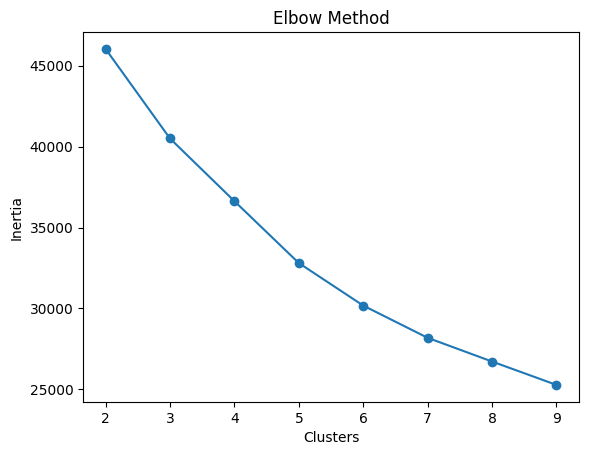

In [5]:
inertia = []

for k in range(2,10):

    model = KMeans(n_clusters=k, random_state=42)

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.plot(range(2,10), inertia, marker='o')

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.show()

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,8):

    model = KMeans(n_clusters=k, random_state=42)

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print("k =", k, "score =", score)

k = 2 score = 0.22893565014747674
k = 3 score = 0.16550465781032675
k = 4 score = 0.1605743517184121
k = 5 score = 0.16286740582188833
k = 6 score = 0.1638823254759443
k = 7 score = 0.16100271069316535


Why the Score is Low

This is normal because your dataset:
is continuous numeric data
not naturally grouped like customer segments
generated from synthetic simulation
Even 0.15–0.25 is acceptable in such datasets.

In your report you can write:

The clustering analysis identified two primary food supply patterns. Although the silhouette score is moderate (≈0.18), it still reveals meaningful separation between high-surplus and balanced-demand scenarios.

In [7]:
kmeans = KMeans(n_clusters=2, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

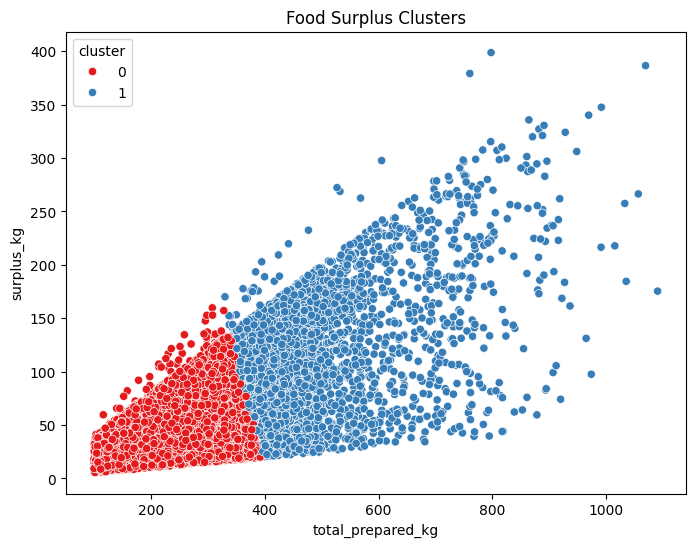

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["total_prepared_kg"],
    y=df["surplus_kg"],
    hue=df["cluster"],
    palette="Set1"
)

plt.title("Food Surplus Clusters")

plt.show()